## Model training

We use data from a file or a function generation to train a perception surrogate $g(\Delta x)$.
In this case $\Delta x$ is defined as the relative position (distance) between a tree and the drone: $\Delta x = \| x - t_i \|$

In [1]:
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import os
import csv
import random
import numpy as np
from scipy.stats import norm 
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch.utils.tensorboard import SummaryWriter
import datetime
import re
import casadi as ca
import l4casadi as l4c
import time

In [2]:

def load_data(polar=False, fixedView=False, ripe=True, n_input=3, subset_ratio=1.0, augment_data=True):
    script_dir = os.getcwd()
    base_dir = os.path.join(script_dir, "datasets")
    
    # Adjust paths based on parameters
    base_dir = os.path.join(base_dir, "polar" if polar else "cartesian")
    base_dir = os.path.join(base_dir, "fixed_view" if fixedView else "variable_view")
    base_dir = os.path.join(base_dir, "ripe" if ripe else "raw")

    output_csv_filename = 'SurrogateDatasetCNN.csv'

    def find_latest_folder(base_dir):
        """Finds the latest dated folder in the base directory."""
        subdirs = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
        latest_folder = max(subdirs, key=lambda d: os.path.getmtime(os.path.join(base_dir, d)))
        return os.path.join(base_dir, latest_folder)

    latest_dataset_folder = find_latest_folder(base_dir=base_dir)

    DATA_PATH = os.path.join(latest_dataset_folder, output_csv_filename)
    print(f"Loading data from: {DATA_PATH}")

    X = []  
    Y = []

    with open(DATA_PATH, 'r') as infile:
        data = csv.reader(infile)
        next(data)  # Skip the header
        for row in data:
            a, b, c, _, value_raw, value_ripe, _ = map(float, row)
            
            if n_input == 3:
                X.append([a, b, c])
            else:
                X.append([a, b])
            
            Y.append( ( value_ripe if ripe else (value_raw)))
    
    X_np = np.array(X)
    Y_np = np.array(Y)
    
    if subset_ratio < 1.0:
        num_samples = int(len(X_np) * subset_ratio)
        indices = np.random.choice(len(X_np), num_samples, replace=False)
        X_np = X_np[indices]
        Y_np = Y_np[indices]
    
    def generate_surrogate_augmented_data(X, num_samples):
        x_min = (np.sqrt(X[:, 0]**2 + X[:, 1]**2)).min()
        x_max = (np.sqrt(X[:, 0]**2 + X[:, 1]**2)).max()
        yaw_values = [30, -30, 60, -60, 90, -90, 180, -180]
        
        synthetic_X = []
        synthetic_Y = []
        
        for _ in range(num_samples):
            theta = random.uniform(-np.pi, np.pi)
            r = random.choice([random.uniform(0, x_min), random.uniform(x_max, x_max +5)])
            a = r * np.cos(theta) 
            b = r * np.sin(theta)
            c = np.radians(random.choice(yaw_values))
            value = 0.5
            synthetic_X.append([a, b, c])
            synthetic_Y.append(value)

        return np.array(synthetic_X), np.array(synthetic_Y)

    if not augment_data: return  torch.tensor(X_np, dtype=torch.float), torch.tensor(Y_np, dtype=torch.float)

    synthetic_X, synthetic_Y = generate_surrogate_augmented_data(X_np, int(len(X_np)*0.2))

    X_tensor = torch.tensor(np.concatenate((X_np, synthetic_X), axis=0), dtype=torch.float)
    Y_tensor = torch.tensor(np.concatenate((Y_np, synthetic_Y), axis=0), dtype=torch.float)
    return X_tensor, Y_tensor

def generate_xytheta_grid(
    samples_xy, 
    x_dimension,
    samples_yaw=None, 
    x_low=-8,
    x_high=8,
    y_low=-8,
    y_high=8,
):
    synthetic_XY = []
    x_range = np.linspace(x_low, x_high, samples_xy)
    y_range = np.linspace(y_low, y_high, samples_xy)
    yaw_range = np.linspace(-np.pi, np.pi, samples_yaw) if samples_yaw is not None else []

    for x in x_range:
        for y in y_range:
            yaw_set = yaw_range if samples_yaw is not None else [np.arctan2(-y, -x)]
            for yaw in yaw_set:
                drone_pos = np.array([x, y, yaw])
                synthetic_XY.append(
                    np.concatenate((drone_pos[:x_dimension]))
                )
    return torch.Tensor(np.array(synthetic_XY))

In [12]:
class MultiLayerPerceptron(torch.nn.Module):
    input_layer: torch.nn.Linear
    hidden_layer: torch.nn.ModuleList
    out_layer: torch.nn.Linear

    def __init__(self, input_dim, hidden_size=64, hidden_layers=3):
        super().__init__()
        in_features = input_dim if input_dim != 3 else input_dim + 1
        self.input_layer = torch.nn.Linear(in_features, hidden_size)
        self.hidden_layer = torch.nn.ModuleList(
            [torch.nn.Linear(hidden_size, hidden_size) for _ in range(hidden_layers)]
        )
        self.out_layer = torch.nn.Linear(hidden_size, 1)

    def forward(self, x):

        if x.shape[-1] == 3:
            sin_cos = torch.cat([torch.sin(x[..., -1:]), torch.cos(x[..., -1:])], dim=-1)
            x = torch.cat([x[..., :-1], sin_cos], dim=-1)
        x = self.input_layer(x)
        for layer in self.hidden_layer:
            x = torch.tanh(layer(x))
        x = self.out_layer(x)
        return x


In [15]:
fixedView = True
is_ripe = True
train = False

nn_input_dim = 3
hidden_size = 8
hidden_layers = 3

validation_split = 0.3
batch_size = 1
epochs = 100

X, Y =  load_data(fixedView=fixedView, ripe=is_ripe)

print("Features shape:", X.shape)
print("Targets shape:", Y.shape)

if   train:
    # Base directory to save models
    base_model_dir = os.path.join(f"saved_models_{nn_input_dim}d",'unity_dataset')
    os.makedirs(base_model_dir, exist_ok=True)
    base_model_dir = os.path.join(base_model_dir,'ripe' if is_ripe else 'raw')
    os.makedirs(base_model_dir, exist_ok=True)

    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    run_model_dir = os.path.join(base_model_dir, timestamp)
    os.makedirs(run_model_dir, exist_ok=True)
    print("Models will be saved in:", run_model_dir)

    X = X[:,:3]
    dataset = TensorDataset(X, Y)

    num_train_samples = int((1 - validation_split) * len(dataset))
    num_val_samples = len(dataset) - num_train_samples
    train_dataset, val_dataset = random_split(dataset, [num_train_samples, num_val_samples])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    model =  MultiLayerPerceptron(input_dim=nn_input_dim, hidden_size=hidden_size, hidden_layers=hidden_layers)
    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    print(model)

    log_dir = f"runs/fcn_{datetime.datetime.now().strftime('%Y)-%m-%d_%H-%M-%S')}"
    writer = SummaryWriter(log_dir)


    best_val_loss = float('inf')

    for epoch in range(epochs):
        model.train()

        train_loss = 0
        for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_idx, (x_batch, y_batch) in enumerate(val_loader):
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                y_pred = model(x_batch)
                loss = criterion(y_pred, y_batch)
                val_loss += loss.item()
        
        avg_val_loss = val_loss / len(val_loader)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        writer.add_scalar('Loss/train', avg_train_loss, epoch)
        writer.add_scalar('Loss/val', avg_val_loss, epoch)
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            model_path = os.path.join(run_model_dir, f"best_model_epoch_{epoch+1}.pth")
            torch.save(model.state_dict(), model_path)
            print(f"Model saved to {model_path}")

    writer.close()

Loading data from: /home/pantheon/drea/neural_mpc/datasets/cartesian/variable_view/raw/2025-03-26_01-17-32/SurrogateDatasetCNN.csv
Features shape: torch.Size([3888, 3])
Targets shape: torch.Size([3888])
Models will be saved in: saved_models_3d/unity_dataset/raw/20250426_154335
MultiLayerPerceptron(
  (input_layer): Linear(in_features=4, out_features=64, bias=True)
  (hidden_layer): ModuleList(
    (0-2): 3 x Linear(in_features=64, out_features=64, bias=True)
  )
  (out_layer): Linear(in_features=64, out_features=1, bias=True)
)
Epoch [1/100] | Train Loss: 0.0037 | Val Loss: 0.0012
Model saved to saved_models_3d/unity_dataset/raw/20250426_154335/best_model_epoch_1.pth
Epoch [2/100] | Train Loss: 0.0008 | Val Loss: 0.0006
Model saved to saved_models_3d/unity_dataset/raw/20250426_154335/best_model_epoch_2.pth
Epoch [3/100] | Train Loss: 0.0007 | Val Loss: 0.0006
Model saved to saved_models_3d/unity_dataset/raw/20250426_154335/best_model_epoch_3.pth
Epoch [4/100] | Train Loss: 0.0007 | Val

In [16]:
def get_latest_best_model(nn_input_dim, ripe):
    # Base directory to save models
    base_model_dir = os.path.join(f"saved_models_{nn_input_dim}d", 'unity_dataset')
    base_model_dir = os.path.join(base_model_dir, 'ripe' if ripe else 'raw')
    # Find the latest best model file
    # List the run directories (assumed to be named with timestamps, e.g., "20250204_153045")
    run_dirs = [d for d in os.listdir(base_model_dir) if os.path.isdir(os.path.join(base_model_dir, d))]
    if not run_dirs:
        raise ValueError(f"No run directories found in: {base_model_dir}")
    
    # Select the latest run directory (using lexicographical order assuming proper timestamp formatting)
    latest_run = max(run_dirs)
    latest_run_dir = os.path.join(base_model_dir, latest_run)
    
    # Within the latest run folder, find all files matching the best model naming pattern
    best_model_files = [
        f for f in os.listdir(latest_run_dir)
        if re.match(r"best_model_epoch_(\d+)\.pth", f)
    ]
    if not best_model_files:
        raise ValueError(f"No best model files found in: {latest_run_dir}")
    
    # Pick the file with the highest epoch number.
    latest_model = max(
        best_model_files,
        key=lambda f: int(re.match(r"best_model_epoch_(\d+)\.pth", f).group(1))
    )
    
    loaded_model = os.path.join(latest_run_dir, latest_model)
    print(f'Loaded model: {loaded_model}')
    return loaded_model

In [17]:
# Create subplots
fig = make_subplots(
    rows=1, cols=2,  # 1 row, 2 columns
    specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}]],  # Both subplots are 3D scatter plots
    subplot_titles=("Ground Truth", "Predicted")  # Titles for each subplot
)

X_nn = generate_xytheta_grid(
    samples_xy=80, 
    samples_yaw=1, 
    x_dimension=3,
    use_fov=False,
    x_low=-8,
    x_high=8,
    y_low=-8,
    y_high=8
)

fig.add_trace(go.Scatter3d(z=Y.flatten(), x=X[:,0], y=X[:,1], name='Ground Truth',mode='markers',marker=dict(
        color=Y.flatten(),  # Color based on z values
        colorscale='Viridis',     # Use Viridis color map
        colorbar=dict(title='Z Value'),  # Add color bar
        size=5,                   # Marker size
        opacity=0.8               # Marker opacity
    ),), row=1, col=1)  # Add to the first subplot


model = MultiLayerPerceptron(input_dim=nn_input_dim, hidden_size=hidden_size, hidden_layers=hidden_layers)
model.load_state_dict(torch.load(get_latest_best_model(nn_input_dim, False)))
model.eval()

X = X[:,:3]

# Model prediction
with torch.no_grad():
    y_test = model(X_nn[:,:3]).detach().numpy()

# Add predicted trace to the second subplot
fig.add_trace(go.Scatter3d(z=y_test.flatten(),x= X_nn[:,0],y= X_nn[:,1],name='Predicted',mode='markers',marker=dict(
        color=y_test.flatten(),  # Color based on z values
        colorscale='Viridis',     # Use Viridis color map
        colorbar=dict(title='Z Value'),  # Add color bar
        size=5,                   # Marker size
        opacity=0.8               # Marker opacity
    )
), row=1, col=2)  # Add to the second subplot

# Update layout
fig.update_layout(
    title_text="Ground Truth vs Predicted",  # Main title
    scene=dict(  # Update the first subplot's scene
        xaxis_title="x1",
        yaxis_title="x2",
        zaxis_title="Output"
    ),
    scene2=dict(  # Update the second subplot's scene
        xaxis_title="x1",
        yaxis_title="x2",
        zaxis_title="Output"
    ),
    showlegend=False  # Hide legend for clarity
)

fig.show()
fig.write_html('nn_surrogate_train_test.html')


# Find the index of the maximum value in y_test
max_index = np.argmax(y_test)
x_best = X_nn[max_index, 0]
y_best = X_nn[max_index, 1]

# Vary the third input (yaw angle) between 0 and 2π
yaw_values = np.linspace(-10, 10, 200)

# Create a new input array with x_best and y_best fixed, and yaw_values varying
X_new = np.column_stack([
    np.full_like(yaw_values, x_best),
    np.full_like(yaw_values, y_best),
    yaw_values
])

# Convert to tensor for model inference
X_new_tensor = torch.tensor(X_new, dtype=torch.float32)

# Model prediction for the new input
with torch.no_grad():
    y_new = model(X_new_tensor).detach().numpy()

# Create a new plot
fig_new = go.Figure()

# Add the trace for the new predictions
fig_new.add_trace(go.Scatter(
    x=np.rad2deg(yaw_values),
    y=y_new.flatten(),
    mode='lines',
    name='Predicted Output',
    line=dict(color='blue', width=2)
))

# Update layout
fig_new.update_layout(
    title_text=f"Output Inference with Fixed (x, y) = ({x_best:.2f}, {y_best:.2f}) and Varying Yaw",
    xaxis_title="Yaw Angle (radians)",
    yaxis_title="Output",
    showlegend=True
)

# Show the plot
fig_new.show()

# Save the plot as HTML
fig_new.write_html('nn_surrogate_varying_yaw.html')

Loaded model: saved_models_3d/unity_dataset/raw/20250426_154335/best_model_epoch_99.pth


## Define the working environment

The problem definition is as follows:

$x$ state of the robot defined by the position of the drone and its velocity [x, y ,z, vx, vy, vz]

$f(x, u)$ state transition function for the drone

$u$ acceleration commands to the drone [ax, ay, az]

$t \in T$ tree positions for the $T$ trees [[tx_1, ty_2], ... , [tx_T, ty_T]]

$\lambda$ belief for the trees maturity confidence [\lambda_1, ..., \lambda_T] (values from 0 to 1). For practicity, it can be seen as part of $x$

$z$ observation vector for the tree maturity confidence [z_1, ..., z_T] (values from 0 to 1)

$g(\Delta x)$ observation surrogate. It is applied to every tree.

$b(\lambda, z)$ bayesian update to the previous belief.

$H(\lambda)$ entropy function for the belief defined (for the case of binary distribution) as: $-\lambda \log{\lambda} - (1-\lambda) \log(1-\lambda)$.

$J(\lambda)$ the cost function of the MPC defined as: $\sum_{1, ..., n} \delta_1 H(\lambda_i) * \delta_2 \Delta x_i^2 + \delta_3 \|u\|$. They correspond to trying to reduce the entropy for each of the trees using $\Delta x_i^2$ to guide the planner when there is no observation, and reduce the control inputs.

The steps of the system are as follows:
1. Load learned $g()$ which works for one tree.
2. Initialize $x$ in a $x_0$ position, $\lambda$ with $0.5$ values for each tree, and $t$ as known.
3. Run the NMPC from $x$ for $N$ iterations. In each step:
  - Compute $\Delta x$ for each tree with the new drone $x$.
  - Get estimation from NN for each tree: $z = g(\Delta x)$.
  - Fuse the estimation in $\lambda$ for each tree: $\lambda_{k} = b(\lambda_{k-1}, z)$
4. Apply the solution from the MPC.
5. Get a real observation.
6. Integrate the real observation into $\lambda$.
7. Go back to step 3.

2.1374262888906864e-05


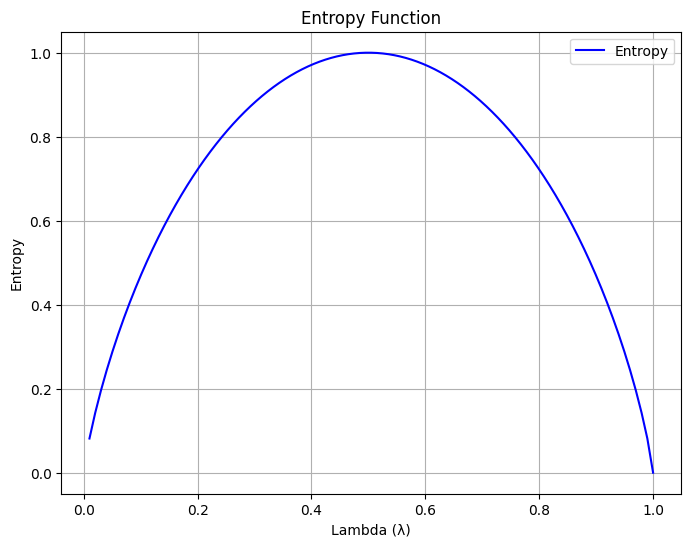

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import casadi as ca
# Define the entropy function
def entropy(lambda_val):
    return (-(lambda_val- 1e-6) * ca.log10(lambda_val -1e-6) - (1 - lambda_val  + 1e-6) * ca.log10(1 - lambda_val  + 1e-6))/ca.log10(2)

# Generate lambda values (avoid 0 and 1 to prevent log(0) errors)
x = np.linspace(0.0, 1.00, 100)
output = []
# Compute entropy values
for i  in range(x.shape[0]):
    output.append(entropy(x[i]))

print(output[-1])
# Plot the entropy function
plt.figure(figsize=(8, 6))
plt.plot(x, output, label="Entropy", color="blue")
plt.title("Entropy Function")
plt.xlabel("Lambda (λ)")
plt.ylabel("Entropy")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
class NeuralMPC:
    def __init__(self, run_dir=None, initial_randomic=False, num_trees=20):
        # Global Constants and Parameters
        self.hidden_size = 64
        self.hidden_layers = 3
        self.nn_input_dim = 3 # [dx, dy, robot_abs_heading]

        self.N = 5  # MPC prediction horizon steps
        self.dt = 0.2 # Time step
        self.T = self.dt * self.N
        self.nx = 3  # Represents [x, y, theta] for pose
        self.n_control = self.nx # Control is effectively acceleration [ax, ay, atheta]
        self.n_state = self.nx * 2 # Full state [x, y, theta, vx, vy, vtheta]
        
        self.NUM_TARGET_TREES = 10 # How many trees to consider for entropy objective
        self.NUM_OBSTACLE_TREES = 2 # How many closest trees to consider for collision avoidance

        self.latest_trees_scores = None # Will be filled by mock sensor
        self.current_robot_state = None # [x,y,theta], updated by MPC commands


        # Mock tree positions
        self.trees_pos = self._get_trees_poses(num_trees)
        self.num_total_trees = self.trees_pos.shape[0]
        
        # True (hidden) states of the trees for mock sensor simulation
        # 0 for unripe, 1 for ripe (example)
        self.true_tree_states = np.random.choice([0.01, 0.99], size=(self.num_total_trees,1)) # Initial true beliefs slightly away from 0/1 for stability

        self.entropy_target = self.entropy_f(self.NUM_TARGET_TREES) # For target subset
        self.entropy_entire_field = self.entropy_f(self.num_total_trees) # For all trees

        # Beliefs about tree states (lambda_k)
        self.lambda_k = ca.DM.ones(self.num_total_trees, 1) * 0.5 # Initial belief: 50/50

        self.mpc_horizon = self.N
        self.baselines_dir = run_dir if run_dir is not None else "./simulation_results"
        os.makedirs(self.baselines_dir, exist_ok=True)
        self.initial_randomic = initial_randomic

        # Mock model path
        self.model_path = self.get_latest_best_model()


    def _get_trees_poses(self, num_trees_x, num_trees_y, space=4.0):
        """Generates random tree positions for the mock simulation."""
        # Example: trees in a 20x20 area
        np.random.seed(42) # For reproducibility
        trees_x = np.random.uniform(0.1, num_trees_x * space, num_trees_x)
        trees_y = np.random.uniform(0.1, num_trees_y * space, num_trees_y)
        return np.column_stack((trees_x, trees_y))

    def _robot_state_update(self):
        """Returns the current mocked robot state [x,y,theta]."""
        if self.current_robot_state is None:
            # Initialize if first time (e.g., to a corner or center)
            lb, ub = self.get_domain(self.trees_pos)
            if self.initial_randomic:
                 self.current_robot_state = self.generate_random_initial_state(lb, ub, margin=1.5).flatten().tolist()
            else:
                self.current_robot_state = [lb[0] + 1.0, (lb[1]+ub[1])/2.0, 0.0] # A fixed start
        return self.current_robot_state

    def _tree_scores_sensor(self):
        """Generates mock tree scores based on robot proximity and true tree states."""
        current_robot_pos_xy = np.array(self.current_robot_state[:2]).flatten()
        
        # Initialize scores to 0.5 (max uncertainty)
        # These scores represent P(measurement = RIPE | true_state_of_tree)
        # Or more directly, the sensor's output z_k which is 0 or 1 (or a probability if sensor is soft)
        mock_scores = np.full((self.num_total_trees, 1), 0.5) 
        
        sensing_radius_sq = 4.0**2  # Robot can sense trees within 3 meters
        prob_correct_reading = 0.9 # Probability sensor gives correct reading for tree type

        for i in range(self.num_total_trees):
            dist_sq = np.sum((current_robot_pos_xy - self.trees_pos[i, :2])**2)
            if dist_sq < sensing_radius_sq:
                # Tree is within sensing range
                true_state_is_ripe = self.true_tree_states[i,0] > 0.5 # Binary true state
                
                if np.random.rand() < prob_correct_reading:
                    # Sensor gives correct reading
                    mock_scores[i,0] = 1.0 if true_state_is_ripe else 0.0
                else:
                    # Sensor gives incorrect reading
                    mock_scores[i,0] = 0.0 if true_state_is_ripe else 1.0

        self.latest_trees_scores = mock_scores

    @staticmethod
    def get_domain(tree_positions):
        x_min = np.min(tree_positions[:, 0])
        x_max = np.max(tree_positions[:, 0])
        y_min = np.min(tree_positions[:, 1])
        y_max = np.max(tree_positions[:, 1])
        return [x_min, y_min], [x_max, y_max]

    @staticmethod
    def kin_model(nx_pose, dt): # nx_pose is 3 (x,y,theta)
        nx_full = nx_pose * 2 # Full state [px,py,pw,vx,vy,vw] = 6
        nu = nx_pose          # Control [ax,ay,aw] = 3
        
        x_sym = ca.SX.sym('x', nx_full)
        u_sym = ca.SX.sym('u', nu)
        
        px, py, pw, vx, vy, vw = [x_sym[i] for i in range(nx_full)]
        ax, ay, aw = [u_sym[i] for i in range(nu)]
        
        x_dot = ca.vertcat(vx, vy, vw, ax, ay, aw)
        f_continuous = ca.Function('f_cont', [x_sym, u_sym], [x_dot])
        
        k1 = f_continuous(x_sym, u_sym)
        k2 = f_continuous(x_sym + dt / 2 * k1, u_sym)
        k3 = f_continuous(x_sym + dt / 2 * k2, u_sym)
        k4 = f_continuous(x_sym + dt * k3, u_sym)
        x_next = x_sym + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
        
        F = ca.Function('F', [x_sym, u_sym], [x_next])
        return F

    @staticmethod
    def bayes(lambda_prev, z):
        z_clipped = ca.fmax(ca.fmin(z, 0.999), 0.001)
        prod = lambda_prev * z_clipped
        denom = prod + (1 - lambda_prev) * (1 - z_clipped)
        return prod / (denom + 1e-9) # Add epsilon to avoid division by zero

    @staticmethod
    def entropy_f(num_targets):
        p = ca.MX.sym(f'input_entropy_f{num_targets}_dim', num_targets)
        p_clipped = ca.fmax(ca.fmin(p, 0.9999), 0.0001)
        output = -4*(p_clipped-0.5)**2 + 1
        return ca.Function(f'entropy_f_{num_targets}_dim', [p], [output])
        
    def get_target_tree_indices(self, robot_position_xy, num_target=None, entropy_threshold=0.025):
        if num_target is None:
            num_target = self.NUM_TARGET_TREES

        robot_pos_1d = np.array(robot_position_xy).flatten()
        distances = np.linalg.norm(self.trees_pos[:, :2] - robot_pos_1d, axis=1)
        
        H_all_trees = self.entropy_entire_field(self.lambda_k)
        H_values = H_all_trees.full().flatten()
        
        candidate_indices = np.where(H_values > entropy_threshold)[0]
        
        if candidate_indices.size == 0:
            print("Warning: No trees above entropy threshold. Selecting nearest overall trees.")
            sorted_indices_all = np.argsort(distances)
            return sorted_indices_all[:num_target]

        sorted_candidates = candidate_indices[np.argsort(distances[candidate_indices])]

        if sorted_candidates.size < num_target:
            repeats = int(np.ceil(num_target / sorted_candidates.size)) if sorted_candidates.size > 0 else num_target
            if sorted_candidates.size > 0:
                sorted_candidates = np.tile(sorted_candidates, repeats)[:num_target]
            else: # Should not happen if the above "if candidate_indices.size == 0" works
                 print("Critical Warning: No candidates and somehow bypassed initial check. Taking overall nearest.")
                 sorted_indices_all = np.argsort(distances)
                 return sorted_indices_all[:num_target]


        return sorted_candidates[:num_target]

    def get_nearest_tree_indices(self, robot_position_xy, num_obstacle=None):
        if num_obstacle is None:
            num_obstacle = self.NUM_OBSTACLE_TREES
        if num_obstacle == 0:
            return np.array([], dtype=int)
        if num_obstacle > self.num_total_trees:
            num_obstacle = self.num_total_trees

        robot_pos_1d = np.array(robot_position_xy).flatten()
        distances = np.linalg.norm(self.trees_pos[:, :2] - robot_pos_1d, axis=1)
        sorted_indices = np.argsort(distances)
        return sorted_indices[:num_obstacle]

    def mpc_opt(self, g_nn, target_trees_subset_pos, target_lambdas_subset, 
                obstacle_trees_subset_pos, lb, ub, x0_full_state, steps_N):

        # Attraction term: encourage getting closer to targets (exponentially decay if far)
        Q_dist = 10.0
        # Control effort penalty
        R_xy_accel = 1e-2
        R_theta_accel = 1e-2
        
        
        opti = ca.Opti()
        F_dynamics = self.kin_model(self.nx, self.dt)

        X_state_traj = opti.variable(self.n_state, steps_N + 1)
        U_control_traj = opti.variable(self.n_control, steps_N)

        num_target_trees_actual = target_trees_subset_pos.shape[0]
        num_obstacle_trees_actual = obstacle_trees_subset_pos.shape[0]
        
        # Parameters for the optimization problem
        # These will be set before each call to solve() or mpc_step()
        P_X0_full = opti.parameter(self.n_state)
        P_TargetTreesPos = opti.parameter(num_target_trees_actual, 2)
        P_TargetLambdas = opti.parameter(num_target_trees_actual)
        P_ObstacleTreesPos = opti.parameter(num_obstacle_trees_actual, 2)

        # Initial condition
        opti.subject_to(X_state_traj[:, 0] == P_X0_full)

        cost_total = 0
        cost_entropy = 0
        cost_attraction = 0
        cost_control_effort = 0
        
        lambda_evolution_over_horizon = [P_TargetLambdas]
        nn_input_batch_over_horizon = []

        # Dynamics, bounds, and costs over the horizon
        for i in range(steps_N):
            # State bounds (position, velocity)
            opti.subject_to(opti.bounded(lb[0] - 3.0, X_state_traj[0, i], ub[0] + 3.0)) # x pos
            opti.subject_to(opti.bounded(lb[1] - 3.0, X_state_traj[1, i], ub[1] + 3.0)) # y pos
            opti.subject_to(opti.bounded(-3*np.pi, X_state_traj[2, i], +3*np.pi))      # theta
            opti.subject_to(opti.bounded(-1.75, X_state_traj[3:5, i], 1.75))           # vx, vy
            opti.subject_to(opti.bounded(-np.pi/4, X_state_traj[5, i], np.pi/4))       # vtheta

            # Control bounds (acceleration)
            opti.subject_to(opti.bounded(-5.0, U_control_traj[0:2, i], 5.0))         # ax, ay
            opti.subject_to(opti.bounded(-np.pi, U_control_traj[2, i], np.pi))       # atheta
            
            # System dynamics
            opti.subject_to(X_state_traj[:, i + 1] == F_dynamics(X_state_traj[:, i], U_control_traj[:, i]))

            # Collision avoidance with OBSTACLE trees
            safe_distance_sq = 1.25**2
            for j in range(num_obstacle_trees_actual):
                obs_j_pos = P_ObstacleTreesPos[j, :]
                dist_sq_obs = ca.sumsqr(X_state_traj[:2, i+1] - obs_j_pos.T)
                opti.subject_to(dist_sq_obs >= safe_distance_sq)

            # Prepare inputs for NN (related to TARGET trees)
            current_nn_input_step_i = []
            min_dist_sq_to_target_this_step = ca.inf
            
            for j in range(num_target_trees_actual):
                target_j_pos = P_TargetTreesPos[j, :]
                diff_robot_to_target = X_state_traj[:2, i + 1] - target_j_pos.T
                dist_sq_target = ca.sumsqr(diff_robot_to_target) + 1e-6 # for numerical stability
                min_dist_sq_to_target_this_step = ca.fmin(min_dist_sq_to_target_this_step, dist_sq_target)
                
                # NN input: [dx, dy, robot_absolute_heading]
                # dx, dy relative to tree
                robot_abs_heading = X_state_traj[2, i+1] 
                nn_input_for_tree_j = ca.horzcat(diff_robot_to_target.T, robot_abs_heading)
                current_nn_input_step_i.append(nn_input_for_tree_j)
            
            nn_input_batch_over_horizon.append(ca.vcat(current_nn_input_step_i))

            cost_attraction = cost_attraction - Q_dist * ca.exp(-(ca.sqrt(min_dist_sq_to_target_this_step) - 2.0)**2 / (2 * 100**2))

            cost_control_effort = cost_control_effort + \
                                  R_xy_accel * ca.sumsqr(U_control_traj[:2, i]) + \
                                  R_theta_accel * ca.sumsqr(U_control_traj[2, i])

        # NN prediction for all target trees over all steps
        # g_nn expects a batch of inputs: (N_steps * N_target_trees, N_features)
        nn_full_batch_input = ca.vcat(nn_input_batch_over_horizon)
        g_nn_output_full_batch = g_nn(nn_full_batch_input) # Output shape: (N_steps * N_target_trees, 1)

        # Bayesian update using NN predictions over the horizon
        z_k_predicted = ca.fmax(g_nn_output_full_batch, 0.5) 
        
        # Extend initial lambdas for processing (L0 has N_target_trees elements)
        L0_extended_for_horizon = ca.vcat([P_TargetLambdas for _ in range(steps_N)])
        
        # If current belief L0 is high (>=0.5, believes ripe), then z_k_bin is z_k (NN's P(measure_ripe))
        # If current belief L0 is low (<0.5, believes unripe), then z_k_bin is 1-z_k (NN's P(measure_unripe))
        z_k_binary_assumption = (L0_extended_for_horizon >= 0.5) * z_k_predicted + \
                                (L0_extended_for_horizon < 0.5) * (1 - z_k_predicted)

        for i in range(steps_N):
            start_idx = i * num_target_trees_actual
            end_idx = (i + 1) * num_target_trees_actual
            z_k_for_step_i = z_k_binary_assumption[start_idx:end_idx]
            
            lambda_next = self.bayes(lambda_evolution_over_horizon[-1], z_k_for_step_i)
            lambda_evolution_over_horizon.append(lambda_next)

        # Entropy reduction objective
        for i in range(1, steps_N + 1): # From k=1 to N
            entropy_at_step_k = self.entropy_target(lambda_evolution_over_horizon[i])
            # sum of future entropies, discounted
            cost_entropy += ca.exp(-0.5*i) * ca.sum1(entropy_at_step_k) # Discount factor for future entropy
            # Original: cost_entropy += ca.exp(-2*i)*ca.logsumexp(-40*entropy_future)

        # Modulation for attraction term based on distance to nearest target from initial position
        sq_dist_to_targets_initial = ca.sumsqr(P_X0_full[:2] - P_TargetTreesPos.T) # sum over x,y; result is per-tree
        min_sq_dist_initial = ca.mmin(sq_dist_to_targets_initial) # min over trees
        
        threshold_sq_dist = (9.0)**2 # e.g., 9 meters
        sigmoid_steepness = 0.1 # Adjusted steepness
        # Sigmoid factor: 0 if very close, 1 if far
        sigmoid_factor = 1.0 / (1.0 + ca.exp(-sigmoid_steepness * (min_sq_dist_initial - threshold_sq_dist)))
        modulated_attraction_term = cost_attraction * sigmoid_factor

        # Total objective
        cost_total = cost_control_effort + 10 * cost_entropy + modulated_attraction_term
        opti.minimize(cost_total)
        
        # IPOPT options (removed HSL specific parts for wider compatibility)
        options = {
            "ipopt": {
                "tol": 1e-5, # Relaxed tol for faster eval
                "warm_start_init_point": "yes",
                "print_level": 0, # Suppress IPOPT output
                "sb": "yes", # Suppress license messages
                "max_iter": 500, # Reduced max_iter
                "hessian_approximation":'limited-memory',
                "mu_strategy": "adaptive", # often better than monotone
            },
            "print_time": False # Suppress CasADi print times
        }
        opti.solver("ipopt", options)

        # Set initial values for parameters
        opti.set_value(P_X0_full, x0_full_state)
        opti.set_value(P_TargetTreesPos, target_trees_subset_pos)
        opti.set_value(P_TargetLambdas, target_lambdas_subset)
        if num_obstacle_trees_actual > 0:
            opti.set_value(P_ObstacleTreesPos, obstacle_trees_subset_pos)
        else: # Handle case with no obstacles
             opti.set_value(P_ObstacleTreesPos, np.empty((0,2)))
        param_inputs_for_func = [P_X0_full, P_TargetTreesPos, P_TargetLambdas, P_ObstacleTreesPos]
        decision_var_inputs_for_func = [opti.x, opti.lam_g]
        
        outputs_for_func = [U_control_traj[:, 0], X_state_traj, opti.x, opti.lam_g]

        # Solve for the first time (cold start)
        try:
            sol = opti.solve()
            u_sol = sol.value(U_control_traj[:, 0])
            x_traj_sol = sol.value(X_state_traj)
            x_dec_sol = sol.value(opti.x) # Full decision variable vector
            lam_g_sol = sol.value(opti.lam_g) # Lagrangian multipliers for constraints
        except RuntimeError as e:
            print(f"IPOPT solve failed: {e}")
            print("Returning zero control and current state as trajectory.")
            u_sol = ca.DM.zeros(self.n_control)
            # Repeat current full state for the trajectory
            x_traj_sol = ca.repmat(x0_full_state.reshape((-1,1)), 1, steps_N + 1) 
            x_dec_sol = opti.initial(opti.x) # Or some default
            lam_g_sol = opti.initial(opti.lam_g) # Or some default

        # Create function AFTER first solve
        mpc_step_func = opti.to_function("mpc_step", 
                                         param_inputs_for_func + decision_var_inputs_for_func, 
                                         outputs_for_func)
        
        return (mpc_step_func,
                ca.DM(u_sol),
                ca.DM(x_traj_sol),
                ca.DM(x_dec_sol),
                ca.DM(lam_g_sol))


    def generate_random_initial_state(self, lb, ub, margin=1.5):
        max_attempts = 100
        for _ in range(max_attempts):
            x = np.random.uniform(lb[0] + margin, ub[0] - margin)
            y = np.random.uniform(lb[1] + margin, ub[1] - margin)
            valid = True
            if self.trees_pos.shape[0] > 0: # Only check if trees exist
                for tree_pos_xy in self.trees_pos[:, :2]:
                    if np.linalg.norm(np.array([x, y]) - tree_pos_xy) < margin:
                        valid = False
                        break
            if valid:
                theta = np.random.uniform(-np.pi, np.pi)
                return np.array([x, y, theta]).reshape(-1,1)
        # Fallback if no valid state found
        print("Warning: Could not find a valid random initial state away from trees. Using a default.")
        return np.array([lb[0] + margin, lb[1] + margin, 0.0]).reshape(-1,1)


    def run_simulation(self, max_sim_time_sec=120, max_iterations=None):
        F_dynamics = self.kin_model(self.nx, self.dt)
        lb_domain, ub_domain = self.get_domain(self.trees_pos)
        
        # Initialize robot state
        initial_pose_xy_theta = self._robot_state_update() # Gets initial state [x,y,theta]
        print(f"Simulation starting from: {initial_pose_xy_theta}")
        
        # Full state: [x, y, theta, vx, vy, vtheta]
        current_velocities_vx_vy_vtheta = ca.DM.zeros(self.nx) 
        current_full_state_x_k = ca.vertcat(ca.DM(initial_pose_xy_theta), current_velocities_vx_vy_vtheta)

        # Simulation data logging
        all_predicted_trajectories = [] # Store full predicted X from MPC
        lambda_history_all_trees = []
        entropy_history_total = []
        mpc_step_durations = []
        actual_pose_history = [] # Store [x,y,theta] at each step
        sim_time_history = []

        sim_start_wall_time = time.time()
        current_sim_logical_time = 0.0
        
        mpciter = 0
        
        is_first_mpc_solve = True
        # Store previous MPC solution for warm start
        prev_mpc_decision_vars_sol = None
        prev_mpc_lagrangian_multipliers_sol = None
        mpc_solver_function = None

        # Main simulation loop
        # Stop if max time reached, or all entropies low, or max iterations
        loop_condition = True
        if max_iterations is None:
            max_iterations = int(max_sim_time_sec / self.dt) + 10 # Generous buffer

        while loop_condition and mpciter < max_iterations:
            loop_iter_start_wall_time = time.time()
            print(f"\nMPC Iteration: {mpciter}, Sim Time: {current_sim_logical_time:.2f}s")

            # Update current robot pose (from previous command) for this iteration
            self.current_robot_state = current_full_state_x_k[:self.nx].full().flatten().tolist()
            actual_pose_history.append(self.current_robot_state)
            sim_time_history.append(current_sim_logical_time)

            # Mock sensor: get tree scores
            self._tree_scores_sensor()
            if self.latest_trees_scores is None:
                print("Error: sensor did not provide scores. Exiting.")
                break
            
            # Bayesian update of beliefs based on sensor scores
            # Original had (mpciter % 2 == 0), implying not every step.
            self.lambda_k = self.bayes(self.lambda_k, ca.DM(self.latest_trees_scores))
            lambda_history_all_trees.append(self.lambda_k.full().flatten().tolist())
            
            current_entropy_values = self.entropy_entire_field(self.lambda_k)
            total_current_entropy = ca.sum1(current_entropy_values).full().flatten()[0]
            entropy_history_total.append(total_current_entropy)
            print(f"Total Entropy: {total_current_entropy:.4f}")

            # Check termination condition (all trees low entropy)
            entropy_threshold_for_termination = 0.05 # More relaxed for mock
            if np.all(current_entropy_values.full().flatten() <= entropy_threshold_for_termination):
                print(f"All tree entropies <= {entropy_threshold_for_termination}. Mission complete.")
                loop_condition = False # This will be the last iteration's processing
            
            if not loop_condition and mpciter > 0: # If mission complete, break before next MPC solve
                 break

            # Select target and obstacle trees for MPC
            robot_pos_xy_for_selection = np.array(self.current_robot_state[:2])
            target_indices = self.get_target_tree_indices(robot_pos_xy_for_selection, num_target=self.NUM_TARGET_TREES)
            obstacle_indices = self.get_nearest_tree_indices(robot_pos_xy_for_selection, num_obstacle=self.NUM_OBSTACLE_TREES)

            target_trees_subset_pos = self.trees_pos[target_indices, :2]
            obstacle_trees_subset_pos = self.trees_pos[obstacle_indices, :2]
            target_lambdas_subset = self.lambda_k[target_indices]

            mpc_solve_start_time = time.time()
            try:
                if is_first_mpc_solve or mpc_solver_function is None:
                    print("Running MPC opt (first step / cold start)...")
                    mpc_solver_function, u_optimal_first_step, x_predicted_traj, \
                    prev_mpc_decision_vars_sol, prev_mpc_lagrangian_multipliers_sol = self.mpc_opt(
                        g_nn, target_trees_subset_pos, target_lambdas_subset, 
                        obstacle_trees_subset_pos, lb_domain, ub_domain, 
                        current_full_state_x_k, steps_N=self.N
                    )
                    is_first_mpc_solve = False
                    print("MPC cold start finished.")
                else:
                    print("Running MPC step (warm start)...")
                    # Prepare parameters for the mpc_solver_function
                    param_values = [current_full_state_x_k, 
                                    target_trees_subset_pos, 
                                    target_lambdas_subset, 
                                    obstacle_trees_subset_pos if obstacle_trees_subset_pos.shape[0]>0 else np.empty((0,2))
                                   ]
                    
                    u_optimal_first_step, x_predicted_traj, \
                    prev_mpc_decision_vars_sol, prev_mpc_lagrangian_multipliers_sol = mpc_solver_function(
                        *(param_values + [prev_mpc_decision_vars_sol, prev_mpc_lagrangian_multipliers_sol])
                    )
                    print("MPC warm start finished.")
                
                mpc_step_duration = time.time() - mpc_solve_start_time
                mpc_step_durations.append(mpc_step_duration)
                print(f"MPC step duration: {mpc_step_duration:.4f} s")

            except Exception as e:
                print(f"Error during MPC optimization at step {mpciter}: {e}")
                print("!!! MPC Solver Failed - Using Zero Acceleration & Ending Sim !!!")
                u_optimal_first_step = ca.DM.zeros(self.n_control) 
                x_predicted_traj = ca.repmat(current_full_state_x_k.reshape((-1,1)), 1, self.N + 1)
                is_first_mpc_solve = True # Force re-optimization if sim continues
                loop_condition = False # End simulation on critical failure
                # return # or break, depending on desired behavior

            all_predicted_trajectories.append(x_predicted_traj[:self.nx, :].full()) # Log pose part

            # Apply the first optimal control to the system dynamics to get next state
            next_full_state_x_k_plus_1 = F_dynamics(current_full_state_x_k, u_optimal_first_step)
            
            # Update system state for the next iteration
            current_full_state_x_k = next_full_state_x_k_plus_1
            
            mpciter += 1
            current_sim_logical_time += self.dt
            
            if time.time() - sim_start_wall_time > max_sim_time_sec:
                print(f"Max simulation wall time {max_sim_time_sec}s reached.")
                loop_condition = False
            
            # Simulate delay for dt (if computation was faster)
            loop_wall_time_elapsed = time.time() - loop_iter_start_wall_time
            sleep_duration = self.dt - loop_wall_time_elapsed
            if sleep_duration > 0 and loop_condition : # Don't sleep if exiting
                # print(f"Sleeping for {sleep_duration:.3f}s to match dt.")
                time.sleep(sleep_duration)
            elif loop_wall_time_elapsed > self.dt:
                 print(f"Warning: Loop iteration {mpciter-1} took {loop_wall_time_elapsed:.3f}s, longer than dt={self.dt}s")


        # --- End of Simulation Loop ---
        total_execution_wall_time = time.time() - sim_start_wall_time
        print(f"\nSimulation Finished. Total wall time: {total_execution_wall_time:.2f}s, Iterations: {mpciter}")

        # Save metrics
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        perf_csv_path = os.path.join(self.baselines_dir, f"mock_mpc_{timestamp}_performance.csv")
        avg_mpc_step_time = np.mean(mpc_step_durations) if mpc_step_durations else 0
        final_entropy_val = entropy_history_total[-1] if entropy_history_total else "N/A"
        
        # Calculate total distance traveled
        total_distance = 0
        if len(actual_pose_history) > 1:
            poses_np = np.array(actual_pose_history)
            total_distance = np.sum(np.linalg.norm(np.diff(poses_np[:,:2], axis=0), axis=1))

        with open(perf_csv_path, mode='w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(["Metric", "Value"])
            writer.writerow(["Total Execution Wall Time (s)", total_execution_wall_time])
            writer.writerow(["Total Simulation Logical Time (s)", current_sim_logical_time])
            writer.writerow(["Total MPC Iterations", mpciter])
            writer.writerow(["Average MPC Step Duration (s)", avg_mpc_step_time])
            writer.writerow(["Final Total Entropy", final_entropy_val])
            writer.writerow(["Total Distance Traveled (m)", total_distance])
        print(f"Performance metrics saved to {perf_csv_path}")

        plot_data_csv_path = os.path.join(self.baselines_dir, f"mock_mpc_{timestamp}_plot_data.csv")
        with open(plot_data_csv_path, mode='w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(["tree_positions_x"] + self.trees_pos[:,0].tolist())
            writer.writerow(["tree_positions_y"] + self.trees_pos[:,1].tolist())
            header = ["sim_time", "robot_x", "robot_y", "robot_theta", "total_entropy"]
            for i in range(self.num_total_trees):
                header.append(f"lambda_tree_{i}")
            writer.writerow(header)
            for i in range(len(sim_time_history)):
                row = [sim_time_history[i]] + actual_pose_history[i] + \
                      [entropy_history_total[i]] + lambda_history_all_trees[i]
                writer.writerow(row)
        print(f"Plot data saved to {plot_data_csv_path}")


        return (actual_pose_history, entropy_history_total, sim_time_history, 
                self.trees_pos, mpc_step_durations, lambda_history_all_trees)


# --- Main Execution ---
# Initialize the NN model (for g_nn)
# This needs to be done once before passing g_nn to mpc_opt
# This model would typically be loaded from a file.
pytorch_model = MultiLayerPerceptron(input_dim=NeuralMPC.nn_input_dim, # Accessing class variable for consistency
                                     hidden_size=NeuralMPC.hidden_size,
                                     hidden_layers=NeuralMPC.hidden_layers)
# Load weights if a real model is available, otherwise it uses random init from create_dummy_model
# For the mock, NeuralMPC handles finding/creating a dummy model file.
# Here we just load from the path it determines.
temp_mpc_for_model_path = NeuralMPC() # Temporary instance to get model path logic
model_load_path = temp_mpc_for_model_path.model_path
del temp_mpc_for_model_path

try:
    pytorch_model.load_state_dict(torch.load(model_load_path, map_location=torch.device('cpu'))) # Ensure CPU for mock
    print(f"Successfully loaded PyTorch model from {model_load_path}")
except Exception as e:
    print(f"Could not load PyTorch model from {model_load_path}, using random weights. Error: {e}")
pytorch_model.eval()

# Convert PyTorch model to L4CasADi model (CasADi symbolic function)
# Use 'cpu' for device in mock to avoid CUDA dependency if not available
g_nn = l4c.L4CasADi(pytorch_model, 
                    model_expects_batch_dim=True, # Assuming model handles batches
                    device='cpu') 
print("g_nn (L4CasADi model) created.")


print("Cell 3: NeuralMPC Class and g_nn setup - Complete")

In [ ]:
# Cell 4: Run the Simulation
# Parameters for the simulation
run_directory = "./simulation_results_mock_run1"
use_random_initial_state = True # True or False
number_of_trees_in_sim = 15   # How many trees in the mock environment
max_simulation_seconds = 180 # Maximum duration of the simulation in seconds
# max_mpc_iterations = 200 # Alternative: set max number of MPC steps

# Create and run the MPC simulation
mpc_mock_instance = NeuralMPC_Mock(run_dir=run_directory, 
                                   initial_randomic=use_random_initial_state,
                                   num_mock_trees=number_of_trees_in_sim)

print(f"True tree states (first 5): {mpc_mock_instance.true_tree_states[:5].flatten()}")

# The g_nn (L4CasADi model) is passed to run_simulation, which then passes to mpc_opt
# This was a bit convoluted in original structure. Simpler if g_nn is member of NeuralMPC_Mock
# For now, let's stick to passing it if mpc_opt is not a member method that can access self.g_nn
# Ah, mpc_opt IS a member, so it can access self.g_nn if we make g_nn a member.
# Let's make g_nn a member of NeuralMPC_Mock, initialized in its __init__
# For now, I'll modify run_simulation to take g_nn as it's cleaner given current structure
# (The provided code calls self.mpc_opt(g_nn, ...), so g_nn is passed)

(   sim_actual_pose_history, 
    sim_entropy_history_total, 
    sim_time_points,
    sim_tree_positions,
    sim_mpc_durations,
    sim_lambda_history
) = mpc_mock_instance.run_simulation(max_sim_time_sec=max_simulation_seconds) #, max_iterations=max_mpc_iterations)

print("\nSimulation run finished. Results collected.")
print(f"Number of time points: {len(sim_time_points)}")
if sim_time_points:
    print(f"Final simulation time: {sim_time_points[-1]:.2f}s")
    print(f"Final robot pose: x={sim_actual_pose_history[-1][0]:.2f}, y={sim_actual_pose_history[-1][1]:.2f}, th={sim_actual_pose_history[-1][2]:.2f}")
    print(f"Final total entropy: {sim_entropy_history_total[-1]:.4f}")
if sim_mpc_durations:
    print(f"Average MPC calculation time: {np.mean(sim_mpc_durations):.4f}s")

In [ ]:
# Cell 5: Plotting Results

if not sim_time_points:
    print("No simulation data to plot.")
else:
    # Extract trajectory data
    poses_array = np.array(sim_actual_pose_history)
    robot_x_coords = poses_array[:, 0]
    robot_y_coords = poses_array[:, 1]

    fig, axs = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})
    fig.suptitle('NMPC Mock Simulation Results', fontsize=16)

    # Subplot 1: Robot Trajectory and Tree Positions
    axs[0].plot(robot_x_coords, robot_y_coords, '-b', label="Robot Trajectory")
    axs[0].scatter(sim_tree_positions[:, 0], sim_tree_positions[:, 1], 
                   c='g', marker='^', label="Tree Positions", s=50)
    
    # Mark start and end points
    axs[0].plot(robot_x_coords[0], robot_y_coords[0], 'ro', markersize=8, label="Start")
    axs[0].plot(robot_x_coords[-1], robot_y_coords[-1], 'rx', markersize=10, mew=2, label="End")
    
    axs[0].set_xlabel("X Position (m)")
    axs[0].set_ylabel("Y Position (m)")
    axs[0].set_title("Robot Trajectory and Environment")
    axs[0].legend()
    axs[0].grid(True)
    axs[0].axis('equal') # Ensure aspect ratio is equal for correct path visualization

    # Subplot 2: Total Entropy Over Time
    axs[1].plot(sim_time_points, sim_entropy_history_total, '-r', label="Total Entropy")
    axs[1].set_xlabel("Time (s)")
    axs[1].set_ylabel("Total Entropy")
    axs[1].set_title("Information Gain (Entropy Reduction) Over Time")
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(bottom=max(0, min(sim_entropy_history_total)-0.1) if sim_entropy_history_total else 0) # Ensure y starts near min entropy but >=0

    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to make space for suptitle
    plt.show()

    # Optional: Plot individual lambda beliefs for a few trees
    if sim_lambda_history and len(sim_lambda_history[0]) > 0:
        num_trees_to_plot = min(5, mpc_mock_instance.num_total_trees)
        lambda_array = np.array(sim_lambda_history)
        
        plt.figure(figsize=(12, 6))
        for i in range(num_trees_to_plot):
            plt.plot(sim_time_points, lambda_array[:, i], label=f"Tree {i} $\lambda_k$ (Belief P(Ripe))")
        
        plt.xlabel("Time (s)")
        plt.ylabel("Belief $\lambda_k$")
        plt.title(f"Belief Evolution for First {num_trees_to_plot} Trees")
        plt.legend()
        plt.grid(True)
        plt.ylim([-0.05, 1.05])
        plt.show()

    # Optional: Plot MPC step durations
    if sim_mpc_durations:
        plt.figure(figsize=(10, 4))
        plt.plot(sim_mpc_durations, marker='o', linestyle='-', label="MPC Step Duration")
        plt.xlabel("MPC Iteration")
        plt.ylabel("Duration (s)")
        plt.title("MPC Computation Time per Step")
        if len(sim_mpc_durations) > 1: # Avoid issues with single point std
             plt.axhline(np.mean(sim_mpc_durations), color='r', linestyle='--', label=f"Mean: {np.mean(sim_mpc_durations):.3f}s")
        plt.legend()
        plt.grid(True)
        plt.show()

print("Cell 5: Plotting - Complete (if data exists)")